### Introduction <a class="anchor" id="Introduction"></a>

Loyal employees are one of the key elements for every organization to maintain its productive and sustainable workflow. Thus, in order to make recruitment smooth, effective and beneficial both employee and  company, it is important to have a clear perception which kind of employees are likely to resign in a short period of time and which would stay loyal longer. 

In this research we will work with exit surveys from employees of the Department of Education, Training and Employment (DETE) and the Technical and Further Education (TAFE) institute in Queensland, Australia. DETE dataset was downloaded [here](https://data.gov.au/dataset/ds-qld-fe96ff30-d157-4a81-851d-215f2a0fe26d/details?q=exit%20survey). Unfortunately, original TAFE exit survey data is no longer available. 

The goal of this research is to combine the results for both surveyes and answer following questions:

* Are employees who only worked for the institutes for a short period of time resigning due to some kind of dissatisfaction? What about employees who have been there longer?

* Are younger employees resigning due to some kind of dissatisfaction? What about older employees?

* Are employees who work for TAFE or DETE institute more likely to resign due to dissatisfaction?

### Loading Data and Data Description <a class="anchor" id="Loading"></a>

First, we import all necessary libraries, read both datasets, and inspect all the information we can use to perform our analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.style as style
import seaborn as sns

In [2]:
dete_survey=pd.read_csv('H:/dete_survey.csv')
tafe_survey=pd.read_csv('H:tafe_survey.csv')

In [3]:
dete_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 56 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   ID                                   822 non-null    int64 
 1   SeparationType                       822 non-null    object
 2   Cease Date                           822 non-null    object
 3   DETE Start Date                      822 non-null    object
 4   Role Start Date                      822 non-null    object
 5   Position                             817 non-null    object
 6   Classification                       455 non-null    object
 7   Region                               822 non-null    object
 8   Business Unit                        126 non-null    object
 9   Employment Status                    817 non-null    object
 10  Career move to public sector         822 non-null    bool  
 11  Career move to private sector        822 non-

In [4]:
dete_survey.head(5)

,ID,SeparationType,Cease Date,DETE Start Date,Role Start Date,Position,Classification,Region,Business Unit,Employment Status,...,Kept informed,Wellness programs,Health & Safety,Gender,Age,Aboriginal,Torres Strait,South Sea,Disability,NESB
0,1,Ill Health Retirement,08/2012,1984,2004,Public Servant,A01-A04,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,N,N,N,Male,56-60,NaN,NaN,NaN,NaN,Yes
1,2,Voluntary Early Retirement (VER),08/2012,Not Stated,Not Stated,Public Servant,AO5-AO7,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,N,N,N,Male,56-60,NaN,NaN,NaN,NaN,NaN
2,3,Voluntary Early Retirement (VER),05/2012,2011,2011,Schools Officer,NaN,Central Office,Education Queensland,Permanent Full-time,...,N,N,N,Male,61 or older,NaN,NaN,NaN,NaN,NaN
3,4,Resignation-Other reasons,05/2012,2005,2006,Teacher,Primary,Central Queensland,NaN,Permanent Full-time,...,A,N,A,Female,36-40,NaN,NaN,NaN,NaN,NaN
4,5,Age Retirement,05/2012,1970,1989,Head of Curriculum/Head of Special Education,NaN,South East,NaN,Permanent Full-time,...,N,A,M,Female,61 or older,NaN,NaN,NaN,NaN,NaN


In [5]:
dete_survey.isnull().sum()

ID                                       0
SeparationType                           0
Cease Date                               0
DETE Start Date                          0
Role Start Date                          0
Position                                 5
Classification                         367
Region                                   0
Business Unit                          696
Employment Status                        5
Career move to public sector             0
Career move to private sector            0
Interpersonal conflicts                  0
Job dissatisfaction                      0
Dissatisfaction with the department      0
Physical work environment                0
Lack of recognition                      0
Lack of job security                     0
Work location                            0
Employment conditions                    0
Maternity/family                         0
Relocation                               0
Study/Travel                             0
Ill Health 

In [6]:
dete_survey['Cease Date'].value_counts()

Cease Date
2012          344
2013          200
01/2014        43
12/2013        40
Not Stated     34
09/2013        34
06/2013        27
07/2013        22
10/2013        20
11/2013        16
08/2013        12
05/2013         7
05/2012         6
04/2014         2
07/2014         2
08/2012         2
04/2013         2
02/2014         2
11/2012         1
09/2010         1
2010            1
2014            1
07/2012         1
09/2014         1
07/2006         1
Name: count, dtype: int64

In [7]:
dete_survey['DETE Start Date'].value_counts()

DETE Start Date
Not Stated    73
2011          40
2007          34
2008          31
2010          27
2012          27
2009          24
2006          23
1970          21
2013          21
1975          21
2005          20
1990          20
1996          19
1999          19
2000          18
1992          18
2004          18
1991          18
1989          17
1976          15
2002          15
1978          15
2003          15
1988          15
1974          14
1980          14
1995          14
1998          14
1997          14
1979          14
1993          13
1986          12
1972          12
1977          11
1971          10
2001          10
1984          10
1969          10
1994          10
1981           9
1983           9
1985           8
1973           8
1987           7
1963           4
1982           4
1968           3
1967           2
1966           1
1965           1
Name: count, dtype: int64

Observations on DETE dataset:

* 56 columns and 822 entries
* Some of the values are missing. There are several columns with less than 50 values
* Columns `Cease Date` and `DETE Start Date`, which are essential for our research, does not contain missing values and all the values seem realistic
* 'Not Stated' values are not indicated as NaN

Here are some of the columns we could potentially use for our research:

* `ID`: An id used to identify the participant of the survey
* `SeparationType`: The reason why the person's employment ended
* `Cease Date`: The year or month the person's employment ended
* `DETE Start Date`: The year the person began employment with the DETE

Now let's inspect TAFE dataset.

In [8]:
tafe_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 72 columns):
 #   Column                                                                                                                                                         Non-Null Count  Dtype  
---  ------                                                                                                                                                         --------------  -----  
 0   Record ID                                                                                                                                                      702 non-null    float64
 1   Institute                                                                                                                                                      702 non-null    object 
 2   WorkArea                                                                                                                                  

In [9]:
tafe_survey.head()

,Record ID,Institute,WorkArea,CESSATION YEAR,Reason for ceasing employment,Contributing Factors. Career Move - Public Sector,Contributing Factors. Career Move - Private Sector,Contributing Factors. Career Move - Self-employment,Contributing Factors. Ill Health,Contributing Factors. Maternity/Family,...,Workplace. Topic:Does your workplace promote a work culture free from all forms of unlawful discrimination?,Workplace. Topic:Does your workplace promote and practice the principles of employment equity?,Workplace. Topic:Does your workplace value the diversity of its employees?,Workplace. Topic:Would you recommend the Institute as an employer to others?,Gender. What is your Gender?,CurrentAge. Current Age,Employment Type. Employment Type,Classification. Classification,LengthofServiceOverall. Overall Length of Service at Institute (in years),LengthofServiceCurrent. Length of Service at current workplace (in years)
0,6.341330e+17,Southern Queensland Institute of TAFE,Non-Delivery (corporate),2010.0,Contract Expired,NaN,NaN,NaN,NaN,NaN,...,Yes,Yes,Yes,Yes,Female,26 30,Temporary Full-time,Administration (AO),1-2,1-2
1,6.341337e+17,Mount Isa Institute of TAFE,Non-Delivery (corporate),2010.0,Retirement,-,-,-,-,-,...,Yes,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN
2,6.341388e+17,Mount Isa Institute of TAFE,Delivery (teaching),2010.0,Retirement,-,-,-,-,-,...,Yes,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN
3,6.341399e+17,Mount Isa Institute of TAFE,Non-Delivery (corporate),2010.0,Resignation,-,-,-,-,-,...,Yes,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN
4,6.341466e+17,Southern Queensland Institute of TAFE,Delivery (teaching),2010.0,Resignation,-,Career Move - Private Sector,-,-,-,...,Yes,Yes,Yes,Yes,Male,41 45,Permanent Full-time,Teacher (including LVT),3-4,3-4


In [10]:
tafe_survey.isnull().sum()

Record ID                                                                      0
Institute                                                                      0
WorkArea                                                                       0
CESSATION YEAR                                                                 7
Reason for ceasing employment                                                  1
                                                                            ... 
CurrentAge. Current Age                                                      106
Employment Type. Employment Type                                             106
Classification. Classification                                               106
LengthofServiceOverall. Overall Length of Service at Institute (in years)    106
LengthofServiceCurrent. Length of Service at current workplace (in years)    106
Length: 72, dtype: int64

In [11]:
tafe_survey['LengthofServiceOverall. Overall Length of Service at Institute (in years)'].value_counts()

LengthofServiceOverall. Overall Length of Service at Institute (in years)
Less than 1 year      147
1-2                   102
3-4                    96
11-20                  89
More than 20 years     71
5-6                    48
7-10                   43
Name: count, dtype: int64

In [12]:
tafe_survey['Reason for ceasing employment'].value_counts()

Reason for ceasing employment
Resignation                 340
Contract Expired            127
Retrenchment/ Redundancy    104
Retirement                   82
Transfer                     25
Termination                  23
Name: count, dtype: int64

Observations on TAFE dataset:

* 72 columns and 702 entries
* Column names are too long and complicated
* Values in `LengthofServiceOverall. Overall Length of Service at Institute (in years)` seem realistic and there are no missing values

Columns that might be useful for our analysis:

* `Record ID`: An id used to identify the participant of the survey
* `Reason for ceasing employment`: The reason why the person's employment ended
* `LengthofServiceOverall. Overall Length of Service at Institute (in years)`: The length of the person's employment (in years)

Observations on both datasets: 

* Datasets contain many of the same columns, but names are different

* Datasets contain many columns which are not necessary for the purpose of current project

* There are multiple columns/answers that indicate an employee resigned because they were dissatisfied.

### Data Cleaning <a class="anchor" id="DC"></a>

* #### Uniforming NaN Values and Dropping Columns <a class="anchor" id="Nan"></a>

We will start with specifying all missing values like `NaN` in DETE dataset and then drop columns which are not necessary for our research.

In [13]:
Dete_survey=pd.read_csv('H:/dete_survey.csv', na_values= 'Not Stated') 

We've read DETE dataset again, but this time we've indicated `Not Stated` values as `NaN`. Now it's time to drop columns we won't use in this project.

In [14]:
dete_survey_updated=dete_survey.drop(dete_survey.columns[28:49],axis=1)

In [15]:
tafe_survey_updated=tafe_survey.drop(tafe_survey.columns[17:66],axis=1)

In [16]:
dete_survey_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   ID                                   822 non-null    int64 
 1   SeparationType                       822 non-null    object
 2   Cease Date                           822 non-null    object
 3   DETE Start Date                      822 non-null    object
 4   Role Start Date                      822 non-null    object
 5   Position                             817 non-null    object
 6   Classification                       455 non-null    object
 7   Region                               822 non-null    object
 8   Business Unit                        126 non-null    object
 9   Employment Status                    817 non-null    object
 10  Career move to public sector         822 non-null    bool  
 11  Career move to private sector        822 non-

In [17]:
tafe_survey_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 23 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   Record ID                                                                  702 non-null    float64
 1   Institute                                                                  702 non-null    object 
 2   WorkArea                                                                   702 non-null    object 
 3   CESSATION YEAR                                                             695 non-null    float64
 4   Reason for ceasing employment                                              701 non-null    object 
 5   Contributing Factors. Career Move - Public Sector                          437 non-null    object 
 6   Contributing Factors. Career Move - Private Sector        

After modifications we've made there are 35 columns in DETE dataset and 23 columns in TAFE.

* #### Cleaning Columns Names  <a class="anchor" id="Names"></a>

Now we have to define which columns exactly we will use for our analysis. As both datasets consist of many of the same columns but with different names we have to make it uniform to combine two datasets correctly. Below are some columns we'll use: 

| dete_survey | tafe_survey  | Definition|
| :--- | :--- | :--- 
| ID   |  Record ID | An id used to identify the participant of the survey| 
| SeparationType | Reason for ceasing employment | The reason why the participant's employment ended |
| Cease Date   |  CESSATION YEAR | The year or month the participant's employment ended|
| DETE Start Date	 |  | The year the participant began employment with the DETE|
|   |  LengthofServiceOverall.Overall Length of Service at Institute (in years) | The length of the person's employment (in years)|
| Age	 | CurrentAge.Current Age | The age of the participant|
| Gender   |  Gender. What is your Gender? | The gender of the participant|

In order to combine dataframes correctly we have to standardize column names.

In [18]:
dete_survey_updated.columns

Index(['ID', 'SeparationType', 'Cease Date', 'DETE Start Date',
       'Role Start Date', 'Position', 'Classification', 'Region',
       'Business Unit', 'Employment Status', 'Career move to public sector',
       'Career move to private sector', 'Interpersonal conflicts',
       'Job dissatisfaction', 'Dissatisfaction with the department',
       'Physical work environment', 'Lack of recognition',
       'Lack of job security', 'Work location', 'Employment conditions',
       'Maternity/family', 'Relocation', 'Study/Travel', 'Ill Health',
       'Traumatic incident', 'Work life balance', 'Workload',
       'None of the above', 'Gender', 'Age', 'Aboriginal', 'Torres Strait',
       'South Sea', 'Disability', 'NESB'],
      dtype='object')

In [19]:
dete_survey_updated.columns=dete_survey_updated.columns.str.lower().str.replace('separationtype', 'separation_type').str.replace(' ','_')

In [20]:
dete_survey_updated.columns

Index(['id', 'separation_type', 'cease_date', 'dete_start_date',
       'role_start_date', 'position', 'classification', 'region',
       'business_unit', 'employment_status', 'career_move_to_public_sector',
       'career_move_to_private_sector', 'interpersonal_conflicts',
       'job_dissatisfaction', 'dissatisfaction_with_the_department',
       'physical_work_environment', 'lack_of_recognition',
       'lack_of_job_security', 'work_location', 'employment_conditions',
       'maternity/family', 'relocation', 'study/travel', 'ill_health',
       'traumatic_incident', 'work_life_balance', 'workload',
       'none_of_the_above', 'gender', 'age', 'aboriginal', 'torres_strait',
       'south_sea', 'disability', 'nesb'],
      dtype='object')

In [21]:
#creating dictionary with new column names for TAFE dataset
mapping_dict = {'Record ID': 'id',
'CESSATION YEAR': 'cease_date',
'Reason for ceasing employment': 'separation_type',
'Gender. What is your Gender?': 'gender',
'CurrentAge. Current Age': 'age',
'Employment Type. Employment Type': 'employment_status',
'Classification. Classification': 'position',
'LengthofServiceOverall. Overall Length of Service at Institute (in years)': 'institute_service',
'LengthofServiceCurrent. Length of Service at current workplace (in years)': 'role_service'}
tafe_survey_updated = tafe_survey_updated.rename(mapper=mapping_dict, axis=1)
tafe_survey_updated.columns

Index(['id', 'Institute', 'WorkArea', 'cease_date', 'separation_type',
       'Contributing Factors. Career Move - Public Sector ',
       'Contributing Factors. Career Move - Private Sector ',
       'Contributing Factors. Career Move - Self-employment',
       'Contributing Factors. Ill Health',
       'Contributing Factors. Maternity/Family',
       'Contributing Factors. Dissatisfaction',
       'Contributing Factors. Job Dissatisfaction',
       'Contributing Factors. Interpersonal Conflict',
       'Contributing Factors. Study', 'Contributing Factors. Travel',
       'Contributing Factors. Other', 'Contributing Factors. NONE', 'gender',
       'age', 'employment_status', 'position', 'institute_service',
       'role_service'],
      dtype='object')

In [22]:
dete_survey_updated.head()

,id,separation_type,cease_date,dete_start_date,role_start_date,position,classification,region,business_unit,employment_status,...,work_life_balance,workload,none_of_the_above,gender,age,aboriginal,torres_strait,south_sea,disability,nesb
0,1,Ill Health Retirement,08/2012,1984,2004,Public Servant,A01-A04,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,False,False,True,Male,56-60,NaN,NaN,NaN,NaN,Yes
1,2,Voluntary Early Retirement (VER),08/2012,Not Stated,Not Stated,Public Servant,AO5-AO7,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,False,False,False,Male,56-60,NaN,NaN,NaN,NaN,NaN
2,3,Voluntary Early Retirement (VER),05/2012,2011,2011,Schools Officer,NaN,Central Office,Education Queensland,Permanent Full-time,...,False,False,True,Male,61 or older,NaN,NaN,NaN,NaN,NaN
3,4,Resignation-Other reasons,05/2012,2005,2006,Teacher,Primary,Central Queensland,NaN,Permanent Full-time,...,False,False,False,Female,36-40,NaN,NaN,NaN,NaN,NaN
4,5,Age Retirement,05/2012,1970,1989,Head of Curriculum/Head of Special Education,NaN,South East,NaN,Permanent Full-time,...,True,False,False,Female,61 or older,NaN,NaN,NaN,NaN,NaN


In [23]:
tafe_survey_updated.head()

,id,Institute,WorkArea,cease_date,separation_type,Contributing Factors. Career Move - Public Sector,Contributing Factors. Career Move - Private Sector,Contributing Factors. Career Move - Self-employment,Contributing Factors. Ill Health,Contributing Factors. Maternity/Family,...,Contributing Factors. Study,Contributing Factors. Travel,Contributing Factors. Other,Contributing Factors. NONE,gender,age,employment_status,position,institute_service,role_service
0,6.341330e+17,Southern Queensland Institute of TAFE,Non-Delivery (corporate),2010.0,Contract Expired,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Female,26 30,Temporary Full-time,Administration (AO),1-2,1-2
1,6.341337e+17,Mount Isa Institute of TAFE,Non-Delivery (corporate),2010.0,Retirement,-,-,-,-,-,...,-,Travel,-,-,NaN,NaN,NaN,NaN,NaN,NaN
2,6.341388e+17,Mount Isa Institute of TAFE,Delivery (teaching),2010.0,Retirement,-,-,-,-,-,...,-,-,-,NONE,NaN,NaN,NaN,NaN,NaN,NaN
3,6.341399e+17,Mount Isa Institute of TAFE,Non-Delivery (corporate),2010.0,Resignation,-,-,-,-,-,...,-,Travel,-,-,NaN,NaN,NaN,NaN,NaN,NaN
4,6.341466e+17,Southern Queensland Institute of TAFE,Delivery (teaching),2010.0,Resignation,-,Career Move - Private Sector,-,-,-,...,-,-,-,-,Male,41 45,Permanent Full-time,Teacher (including LVT),3-4,3-4


Now, when we have the same names of equivalent columns in both datasets we can proceed with further data cleaning.

* #### Removing Unnecessary Data  <a class="anchor" id="#RemD"></a>

It's time to leave only the data necessary to unswer following question: are employees who have only worked for the institutes for a short period of time resigning due to some kind of dissatisfaction? What about employees who have been at the job longer?

In [24]:
dete_survey_updated['separation_type'].value_counts()

separation_type
Age Retirement                          285
Resignation-Other reasons               150
Resignation-Other employer               91
Resignation-Move overseas/interstate     70
Voluntary Early Retirement (VER)         67
Ill Health Retirement                    61
Other                                    49
Contract Expired                         34
Termination                              15
Name: count, dtype: int64

In [25]:
tafe_survey_updated['separation_type'].value_counts()

separation_type
Resignation                 340
Contract Expired            127
Retrenchment/ Redundancy    104
Retirement                   82
Transfer                     25
Termination                  23
Name: count, dtype: int64

We should only consider respondents who resigned. If we check `separation_type` columns in both dataframes we can see that in `dete_survey_updated`  there are 3 types of resignment: `Resignation-Other reasons`, `Resignation-Other employer`,`Resignation-Move overseas/interstate` and we have to consider all this 3 types. While in `tafe_survey_updated` it's only `Resignition` and other types of separation.

In [26]:
dete_survey_updated['separation_type']=dete_survey_updated['separation_type'].copy().str.extract(r"(Resignation)")

In [27]:
dete_survey_updated['separation_type'].value_counts()

separation_type
Resignation    311
Name: count, dtype: int64

In [28]:
dete_resignations=dete_survey_updated

In [29]:
dete_resignations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   id                                   822 non-null    int64 
 1   separation_type                      311 non-null    object
 2   cease_date                           822 non-null    object
 3   dete_start_date                      822 non-null    object
 4   role_start_date                      822 non-null    object
 5   position                             817 non-null    object
 6   classification                       455 non-null    object
 7   region                               822 non-null    object
 8   business_unit                        126 non-null    object
 9   employment_status                    817 non-null    object
 10  career_move_to_public_sector         822 non-null    bool  
 11  career_move_to_private_sector        822 non-

In [30]:
tafe_survey_updated['separation_type']=tafe_survey_updated['separation_type'].copy().str.extract(r"(Resignation)")

In [31]:
tafe_survey_updated['separation_type'].value_counts()

separation_type
Resignation    340
Name: count, dtype: int64

In [32]:
tafe_resignations=tafe_survey_updated

In [33]:
tafe_resignations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 23 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   702 non-null    float64
 1   Institute                                            702 non-null    object 
 2   WorkArea                                             702 non-null    object 
 3   cease_date                                           695 non-null    float64
 4   separation_type                                      340 non-null    object 
 5   Contributing Factors. Career Move - Public Sector    437 non-null    object 
 6   Contributing Factors. Career Move - Private Sector   437 non-null    object 
 7   Contributing Factors. Career Move - Self-employment  437 non-null    object 
 8   Contributing Factors. Ill Health                     437 non-null    o

We've modified our initial databases in order to leave only the data that coresponds our goal.

* #### Verifying the Data <a class="anchor" id="Ver"></a>

Now let's try to avoid mistakes that might have been caused by corrupted data.
We'll check if years in `cease_date` and `dete_start_date` columns make sense. Since the `cease_date` is the last year of the person's employment and the `dete_start_date` is the person's first year, it wouldn't make sense to have years after the current date. Given that most people in this field start working in their 20s, it's also unlikely that the `dete_start_date` was before the year 1940.

In [34]:
dete_resignations['cease_date'].value_counts()

cease_date
2012          344
2013          200
01/2014        43
12/2013        40
Not Stated     34
09/2013        34
06/2013        27
07/2013        22
10/2013        20
11/2013        16
08/2013        12
05/2013         7
05/2012         6
04/2014         2
07/2014         2
08/2012         2
04/2013         2
02/2014         2
11/2012         1
09/2010         1
2010            1
2014            1
07/2012         1
09/2014         1
07/2006         1
Name: count, dtype: int64

We can see that all data seem realistic, however representation is not consistent and there are 11 missing values idicated as 'Not Stated'. 

We can see that in some years month is indicated while in others it's not. As we don't need to know the exact month of cease date for our analysis, we can leave only the year. 

In [35]:
dete_resignations['cease_date']=dete_resignations['cease_date'].astype('string')

In [36]:
dete_resignations['cease_date'].value_counts()

cease_date
2012          344
2013          200
01/2014        43
12/2013        40
Not Stated     34
09/2013        34
06/2013        27
07/2013        22
10/2013        20
11/2013        16
08/2013        12
05/2013         7
05/2012         6
04/2014         2
07/2014         2
08/2012         2
04/2013         2
02/2014         2
11/2012         1
09/2010         1
2010            1
2014            1
07/2012         1
09/2014         1
07/2006         1
Name: count, dtype: Int64

In [37]:
dete_resignations['cease_date']=dete_resignations['cease_date'].copy().str.extract(r"(?P<Years>[2][0][0-1][0-9])")

In [38]:
dete_resignations['cease_date'].value_counts()

cease_date
2013    380
2012    354
2014     51
2010      2
2006      1
Name: count, dtype: Int64

In [39]:
dete_resignations['cease_date']=dete_resignations['cease_date'].dropna().astype(float,copy=True,errors='raise')

In [40]:
dete_resignations['cease_date'].value_counts().sort_index(ascending= False)

cease_date
2014.0     51
2013.0    380
2012.0    354
2010.0      2
2006.0      1
Name: count, dtype: int64

In [41]:
dete_resignations['dete_start_date'].value_counts().sort_index(ascending= False)

dete_start_date
Not Stated    73
2013          21
2012          27
2011          40
2010          27
2009          24
2008          31
2007          34
2006          23
2005          20
2004          18
2003          15
2002          15
2001          10
2000          18
1999          19
1998          14
1997          14
1996          19
1995          14
1994          10
1993          13
1992          18
1991          18
1990          20
1989          17
1988          15
1987           7
1986          12
1985           8
1984          10
1983           9
1982           4
1981           9
1980          14
1979          14
1978          15
1977          11
1976          15
1975          21
1974          14
1973           8
1972          12
1971          10
1970          21
1969          10
1968           3
1967           2
1966           1
1965           1
1963           4
Name: count, dtype: int64

There are 28 rows in `'dete_start_date` where the year is not indicated. As we have to calculate the length of the service, and without the year when employee has started it's not possible we can drop this values.

In [42]:
dete_resignations['dete_start_date']=dete_resignations['dete_start_date'].str.extract(r"(?P<Years>[1-2][0-9]{3})")

In [43]:
dete_resignations['dete_start_date']=dete_resignations['dete_start_date'].dropna().astype(float)

In [44]:
dete_resignations['dete_start_date'].value_counts().sort_index(ascending= False)

dete_start_date
2013.0    21
2012.0    27
2011.0    40
2010.0    27
2009.0    24
2008.0    31
2007.0    34
2006.0    23
2005.0    20
2004.0    18
2003.0    15
2002.0    15
2001.0    10
2000.0    18
1999.0    19
1998.0    14
1997.0    14
1996.0    19
1995.0    14
1994.0    10
1993.0    13
1992.0    18
1991.0    18
1990.0    20
1989.0    17
1988.0    15
1987.0     7
1986.0    12
1985.0     8
1984.0    10
1983.0     9
1982.0     4
1981.0     9
1980.0    14
1979.0    14
1978.0    15
1977.0    11
1976.0    15
1975.0    21
1974.0    14
1973.0     8
1972.0    12
1971.0    10
1970.0    21
1969.0    10
1968.0     3
1967.0     2
1966.0     1
1965.0     1
1963.0     4
Name: count, dtype: int64

In [45]:
tafe_resignations['cease_date'].value_counts()

cease_date
2011.0    268
2012.0    235
2010.0    103
2013.0     85
2009.0      4
Name: count, dtype: int64

All years indicated in `cease_date` column in both datasets seem realistic, as well as `dete_start_date` in Dete dataset. However, we are not ready to combine our datasets yet.

### Data Processing <a class="anchor" id="DP"></a>

* #### Creating 'institute_service' Column for DETE dataset <a class="anchor" id="#Cr"></a>

`Tafe resignations` dataset has `institute_service` column, to proceed with our analysis we have to create corresponding column in `dete resignations`.

We'll inspect Dete dataset to check if we have columns to calculate the length of time the employee spent in their workplace.

In [46]:
dete_resignations.head()

,id,separation_type,cease_date,dete_start_date,role_start_date,position,classification,region,business_unit,employment_status,...,work_life_balance,workload,none_of_the_above,gender,age,aboriginal,torres_strait,south_sea,disability,nesb
0,1,NaN,2012.0,1984.0,2004,Public Servant,A01-A04,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,False,False,True,Male,56-60,NaN,NaN,NaN,NaN,Yes
1,2,NaN,2012.0,NaN,Not Stated,Public Servant,AO5-AO7,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,False,False,False,Male,56-60,NaN,NaN,NaN,NaN,NaN
2,3,NaN,2012.0,2011.0,2011,Schools Officer,NaN,Central Office,Education Queensland,Permanent Full-time,...,False,False,True,Male,61 or older,NaN,NaN,NaN,NaN,NaN
3,4,Resignation,2012.0,2005.0,2006,Teacher,Primary,Central Queensland,NaN,Permanent Full-time,...,False,False,False,Female,36-40,NaN,NaN,NaN,NaN,NaN
4,5,NaN,2012.0,1970.0,1989,Head of Curriculum/Head of Special Education,NaN,South East,NaN,Permanent Full-time,...,True,False,False,Female,61 or older,NaN,NaN,NaN,NaN,NaN


In order to calculate service time we can use two columns: `dete_start_date` and `cease_date` and create new column `institute_service`. We can see that `cease_date` column has `.float` type, while `dete_start_date` - `.integer` or `.string`. We should convert `dete_start_date` to `.float` too in order to proceed with substraction.

In [47]:
dete_resignations['dete_start_date']=dete_resignations['dete_start_date'].astype('float')

In [48]:
dete_resignations['institute_service']=dete_resignations['cease_date']-dete_resignations['dete_start_date']

In [49]:
dete_resignations['institute_service'].value_counts()

institute_service
1.0     36
5.0     34
3.0     31
0.0     31
4.0     28
6.0     27
2.0     23
22.0    22
37.0    21
9.0     20
15.0    18
13.0    18
43.0    17
7.0     17
23.0    17
24.0    16
17.0    16
21.0    15
16.0    15
38.0    15
35.0    14
8.0     14
12.0    14
14.0    14
39.0    14
11.0    13
19.0    13
42.0    13
10.0    13
34.0    12
32.0    12
20.0    12
41.0    11
33.0    11
18.0    11
26.0    11
31.0    10
25.0    10
29.0     8
28.0     8
40.0     8
44.0     7
27.0     7
36.0     7
45.0     5
30.0     4
49.0     3
46.0     1
50.0     1
48.0     1
Name: count, dtype: int64

We've created new column which indicates the length of the service for Dete dataset. All the values seem realistic, minimum value is 0, that means employee has been working for Dete less then a year, and maximim value is 50 years, that's possible too if person starts to work at 20th and finishes at 70th.

* #### Identifying Dissatisfied Employees TAFE <a class="anchor" id="#DET"></a>

Next we have to identify employees who resigned because they were dissatisfied.
First we have to identify columns which indicate dissatisfaction.

In [50]:
tafe_survey_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 23 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   702 non-null    float64
 1   Institute                                            702 non-null    object 
 2   WorkArea                                             702 non-null    object 
 3   cease_date                                           695 non-null    float64
 4   separation_type                                      340 non-null    object 
 5   Contributing Factors. Career Move - Public Sector    437 non-null    object 
 6   Contributing Factors. Career Move - Private Sector   437 non-null    object 
 7   Contributing Factors. Career Move - Self-employment  437 non-null    object 
 8   Contributing Factors. Ill Health                     437 non-null    o

If we analyse column names we can detect 2 columns which can correspond our needs for `tafe_survey_updated` dataset:
* Contributing Factors. Dissatisfaction
* Contributing Factors. Job Dissatisfaction 

In [51]:
tafe_survey_updated['Contributing Factors. Dissatisfaction'].value_counts()

Contributing Factors. Dissatisfaction
-                                         371
Contributing Factors. Dissatisfaction      66
Name: count, dtype: int64

In [52]:
tafe_survey_updated['Contributing Factors. Job Dissatisfaction'].value_counts()

Contributing Factors. Job Dissatisfaction
-                      360
Job Dissatisfaction     77
Name: count, dtype: int64

In [53]:
tafe_factors=['Contributing Factors. Dissatisfaction','Contributing Factors. Job Dissatisfaction'] 

Now we have to combine two columns into one, we will create `dissatisfied` for both datasets. Employee will be marked as dissatisfied in case one of the factors in any column is indicated so. This column would contain following values:
* True:  a person resigned because of dissatisfaction with the job
* False: a person resigned because of a reason other than dissatisfaction with the job
* NaN: indicates the value is missing

In [54]:
def update_vals(val): # function which conversts information in columns to boolean type
    if pd.isnull(val):
        return np.nan
    elif val=='-':
        return False
    else:
        return True

In [59]:
tafe_resignations['dissatisfied']=tafe_resignations[tafe_factors].applymap(update_vals).any(axis=1, skipna=False)
tafe_resignations.head(5)

C:\Users\rancati\AppData\Local\Temp\24\ipykernel_44460\399802534.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tafe_resignations['dissatisfied']=tafe_resignations[tafe_factors].applymap(update_vals).any(axis=1, skipna=False)


,id,Institute,WorkArea,cease_date,separation_type,Contributing Factors. Career Move - Public Sector,Contributing Factors. Career Move - Private Sector,Contributing Factors. Career Move - Self-employment,Contributing Factors. Ill Health,Contributing Factors. Maternity/Family,...,Contributing Factors. Travel,Contributing Factors. Other,Contributing Factors. NONE,gender,age,employment_status,position,institute_service,role_service,dissatisfied
0,6.341330e+17,Southern Queensland Institute of TAFE,Non-Delivery (corporate),2010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Female,26 30,Temporary Full-time,Administration (AO),1-2,1-2,True
1,6.341337e+17,Mount Isa Institute of TAFE,Non-Delivery (corporate),2010.0,NaN,-,-,-,-,-,...,Travel,-,-,NaN,NaN,NaN,NaN,NaN,NaN,False
2,6.341388e+17,Mount Isa Institute of TAFE,Delivery (teaching),2010.0,NaN,-,-,-,-,-,...,-,-,NONE,NaN,NaN,NaN,NaN,NaN,NaN,False
3,6.341399e+17,Mount Isa Institute of TAFE,Non-Delivery (corporate),2010.0,Resignation,-,-,-,-,-,...,Travel,-,-,NaN,NaN,NaN,NaN,NaN,NaN,False
4,6.341466e+17,Southern Queensland Institute of TAFE,Delivery (teaching),2010.0,Resignation,-,Career Move - Private Sector,-,-,-,...,-,-,-,Male,41 45,Permanent Full-time,Teacher (including LVT),3-4,3-4,False


In [60]:
tafe_resignations_up=tafe_resignations.copy()

* #### Identifying Dissatisfied Employees DETE <a class="anchor" id="#DED"></a>

Now we'll apply the logic we've used above for Tafe dataset to Dete.

In [61]:
dete_survey_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   822 non-null    int64  
 1   separation_type                      311 non-null    object 
 2   cease_date                           788 non-null    float64
 3   dete_start_date                      749 non-null    float64
 4   role_start_date                      822 non-null    object 
 5   position                             817 non-null    object 
 6   classification                       455 non-null    object 
 7   region                               822 non-null    object 
 8   business_unit                        126 non-null    object 
 9   employment_status                    817 non-null    object 
 10  career_move_to_public_sector         822 non-null    bool   
 11  career_move_to_private_sector   

There are several columns which corresponds our response in `dete_survey_updated`:
* job_dissatisfaction
* dissatisfaction_with_the_department
* physical_work_environment
* lack_of_recognition
* lack_of_job_security
* work_location
* employment_conditions
* work_life_balance
* workload

In [62]:
dete_factors=['job_dissatisfaction','dissatisfaction_with_the_department','physical_work_environment','lack_of_recognition','lack_of_job_security','work_location','employment_conditions','work_life_balance','workload']

All the values in columns we are interrested in Dete dataset are boolean type and there are no missing values. So, at this point our goal is only to create new column 'dissatisfied' instead of several which indicate dissatisfaction of the employee. 

In [63]:
dete_resignations['dissatisfied']=dete_resignations[dete_factors].any(axis=1,skipna=False)

In [64]:
dete_resignations['dissatisfied'].value_counts()

dissatisfied
False    447
True     375
Name: count, dtype: int64

In [65]:
dete_resignations_up=dete_resignations.copy()

* #### Combining the Data <a class="anchor" id="#COM"></a>

Now, we've ready to combine data from Tafe and Dete datasets. Our goal is to aggerate the data according to the `institute_service`.

First we'll add a column to each dataframe that will allow us to easily distinguish between the two.

In [66]:
dete_resignations_up['institute']='DETE'

In [67]:
tafe_resignations_up['institute']='TAFE'

In [68]:
combined=pd.concat([dete_resignations_up,tafe_resignations_up],ignore_index=True)

In [69]:
combined_updated=combined.dropna(thresh = 500,axis=1).copy()

* #### Uniforming 'Institute Service' Column <a class="anchor" id="#IS"></a>

Finally we've combined two datasets and almost ready for our research. As our analysis is based on the lenght of service let's have a closer look on `institute_seevice` column and see if the values are uniform.

In [70]:
combined_updated['institute_service'].value_counts(dropna=False)

institute_service
NaN                   209
Less than 1 year      147
1-2                   102
3-4                    96
11-20                  89
More than 20 years     71
5-6                    48
7-10                   43
1.0                    36
5.0                    34
0.0                    31
3.0                    31
4.0                    28
6.0                    27
2.0                    23
22.0                   22
37.0                   21
9.0                    20
15.0                   18
13.0                   18
7.0                    17
43.0                   17
23.0                   17
24.0                   16
17.0                   16
38.0                   15
16.0                   15
21.0                   15
39.0                   14
12.0                   14
35.0                   14
14.0                   14
8.0                    14
10.0                   13
42.0                   13
11.0                   13
19.0                   13
34.0                

To proceed with analysis we'll convert numbers into categories based on a length of the cervise:

* New: Less than 3 years at a company
* Experienced: 3-6 years at a company
* Established: 7-10 years at a company
* Veteran: 11 or more years at a company

When we check `institute_service` column we can see that data is not consistent, so, to categorise this column correctly we need to modify it. Please note that modifications has been made speciffically to categorise the values based on the classification above, so some assumptions has been made to make this process smoother, for example, we replace 1-2 years period with 2 and 7-10 with 7 etc., so it fits our classification easily.

In [71]:
combined_updated['institute_service']=(combined_updated['institute_service'].astype(str).str.replace('Less than 1 year','1').str.replace('More than 20 years','20').str.replace('1-2','2').str.replace('3-4','3').str.replace('5-6','5').str.replace('7-10','7')).astype(float)

In [72]:
combined_updated['institute_service'].value_counts(dropna=False)

institute_service
NaN      209
1.0      183
3.0      127
2.0      125
120.0     89
20.0      83
5.0       82
7.0       60
0.0       31
4.0       28
6.0       27
22.0      22
37.0      21
9.0       20
15.0      18
13.0      18
23.0      17
43.0      17
17.0      16
24.0      16
38.0      15
16.0      15
21.0      15
35.0      14
8.0       14
12.0      14
14.0      14
39.0      14
42.0      13
11.0      13
10.0      13
19.0      13
32.0      12
34.0      12
33.0      11
26.0      11
18.0      11
41.0      11
25.0      10
31.0      10
29.0       8
40.0       8
28.0       8
44.0       7
27.0       7
36.0       7
45.0       5
30.0       4
49.0       3
46.0       1
50.0       1
48.0       1
Name: count, dtype: int64

Next we'll create a function that maps each year value to one of the career stages.

In [73]:
def career_stage(val):
    if pd.isnull(val):
        return np.nan
    elif val<3:
        return 'New'
    elif (val>=3)&(val<=6):
        return 'Experienced'
    elif (val>=7)&(val<10):
        return 'Established'
    else: 
        return 'Veteran'

In [74]:
combined_updated['service_cat']=combined_updated['institute_service'].apply(career_stage)

In [75]:
combined_updated['service_cat'].value_counts(dropna=False)

service_cat
Veteran        618
New            339
Experienced    264
NaN            209
Established     94
Name: count, dtype: int64

We've created a new column, that categorizes employees according to the amount of years spent in their workplace. 

### Data Analysis <a class="anchor" id="DA"></a>

* #### Dealing with Missing Values <a class="anchor" id="#DM"></a>

In [76]:
combined_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1524 entries, 0 to 1523
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1524 non-null   float64
 1   separation_type                      651 non-null    object 
 2   cease_date                           1483 non-null   float64
 3   dete_start_date                      749 non-null    float64
 4   role_start_date                      822 non-null    object 
 5   position                             1413 non-null   object 
 6   region                               822 non-null    object 
 7   employment_status                    1413 non-null   object 
 8   career_move_to_public_sector         822 non-null    object 
 9   career_move_to_private_sector        822 non-null    object 
 10  interpersonal_conflicts              822 non-null    object 
 11  job_dissatisfaction           

In [77]:
combined_updated['dissatisfied'].value_counts(dropna=False)

dissatisfied
False    769
True     755
Name: count, dtype: int64

We can see that there are 265 missing values in the column which indicates our main criteria - if an employee was dissatisfied or not. We will fill it with most frequent value in this column - False. This means - if there is no information that employee was dissatisfied we assume this person was happy with the job.

In [78]:
combined_updated['dissatisfied']=combined_updated['dissatisfied'].fillna(False)
combined_updated['dissatisfied'].value_counts(dropna=False)

dissatisfied
False    769
True     755
Name: count, dtype: int64

There are also missing values in `service_cat` category which indicates category of length of service. We will drop this values.

In [79]:
combined_updated['service_cat']=combined_updated['service_cat'].dropna()

* #### Calculating Percentage of Dissatisfied Employees Depending on Length of Service <a class="anchor" id="#DL"></a>

Now we can finally calculate persenage of dissatisfied employees in each of the service categories.

<Figure size 1200x700 with 0 Axes>

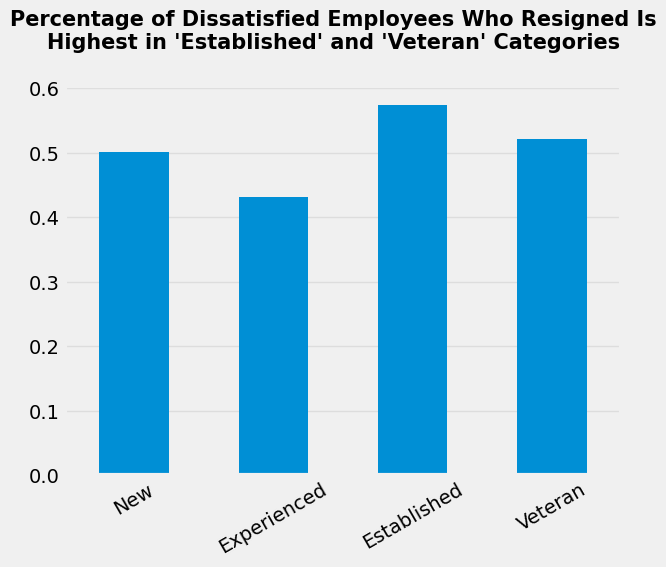

In [80]:
dissat_stat_length=combined_updated.pivot_table(values='dissatisfied',index='service_cat')
style.use('fivethirtyeight')
plt.figure(figsize=(12, 7))
new_order = ["New", "Experienced", "Established", "Veteran"]
dissat_stat_length = dissat_stat_length.reindex(new_order)
#dissat_stat_length.plot(kind='bar',title='Percentage of dissatisfied employees depending on a length of service',)
dissat_stat_length.plot(kind='bar',legend=False,rot=30)
plt.suptitle("Percentage of Dissatisfied Employees Who Resigned Is\n\
Highest in 'Established' and 'Veteran' Categories", ha="center", weight='bold', size=15, x=0.5, y=1.04)
plt.xlabel('')
plt.grid(axis='x', visible=False)
plt.grid(axis='y', alpha=0.5)
plt.show()

As we can see on a bar plot above 'Established' and 'Veteran' employees, in other words people who work 7 eyars and more, resign more often due to some kind of dissatisfaction.   

In [81]:
dete_survey_updated.head()

,id,separation_type,cease_date,dete_start_date,role_start_date,position,classification,region,business_unit,employment_status,...,none_of_the_above,gender,age,aboriginal,torres_strait,south_sea,disability,nesb,institute_service,dissatisfied
0,1,NaN,2012.0,1984.0,2004,Public Servant,A01-A04,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,True,Male,56-60,NaN,NaN,NaN,NaN,Yes,28.0,True
1,2,NaN,2012.0,NaN,Not Stated,Public Servant,AO5-AO7,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,False,Male,56-60,NaN,NaN,NaN,NaN,NaN,NaN,False
2,3,NaN,2012.0,2011.0,2011,Schools Officer,NaN,Central Office,Education Queensland,Permanent Full-time,...,True,Male,61 or older,NaN,NaN,NaN,NaN,NaN,1.0,False
3,4,Resignation,2012.0,2005.0,2006,Teacher,Primary,Central Queensland,NaN,Permanent Full-time,...,False,Female,36-40,NaN,NaN,NaN,NaN,NaN,7.0,False
4,5,NaN,2012.0,1970.0,1989,Head of Curriculum/Head of Special Education,NaN,South East,NaN,Permanent Full-time,...,False,Female,61 or older,NaN,NaN,NaN,NaN,NaN,42.0,True


* #### Calculating Percentage of Dissatisfied Employees Depending on Age <a class="anchor" id="#DA"></a>

Now let's check how age of the imployee affects job dissatisfaction. Firts let's inspect and clean `age` column.

In [82]:
combined_updated['age'].value_counts(dropna=False)

age
61 or older      222
51-55            185
56-60            174
56 or older      162
NaN              117
41  45            80
46-50             63
41-45             61
46  50            59
26-30             57
31  35            52
36-40             51
36  40            51
26  30            50
21  25            44
21-25             40
31-35             39
20 or younger     17
Name: count, dtype: int64

We can see that 117 values are missing and data in `age` column isn't consistent. First we have to clean the values and then we can devide employees in our dataset into 4 groups according to the [classification](https://www.beresfordresearch.com/age-range-by-generation/):

* Gen Z: 27 or younger
* Millennials: 28-43 
* Gen X: 44-59 
* Boomers: 60 or older

In [83]:
combined_updated['age_cat']=(combined_updated['age'].str.extract(r"(\d+)")).astype('float')

In [84]:
combined_updated['age_cat'].value_counts(dropna=False)

age_cat
56.0    336
61.0    222
51.0    185
41.0    141
46.0    122
NaN     117
26.0    107
36.0    102
31.0     91
21.0     84
20.0     17
Name: count, dtype: int64

In [85]:
def age_classification(val):
    if pd.isnull(val):
        return np.nan
    elif val<=27:
        return 'Gen Z'
    elif (val>=28)&(val<=43):
        return 'Millennials'
    elif (val>=44)&(val<=59):
        return 'Gen X'
    else:
        return 'Boomers'

In [86]:
combined_updated['age_cat']=combined_updated['age_cat'].apply(age_classification)

In [87]:
combined_updated['age_cat'].value_counts(dropna=False)

age_cat
Gen X          643
Millennials    334
Boomers        222
Gen Z          208
NaN            117
Name: count, dtype: int64

Now we have to decide what to do with employees with missing data in age column. We will drop this values.

In [88]:
combined_updated['age_cat']=combined_updated['age_cat'].dropna()  #dropping missing values

In [89]:
combined_updated['age_cat'].value_counts(dropna=False)

age_cat
Gen X          643
Millennials    334
Boomers        222
Gen Z          208
NaN            117
Name: count, dtype: int64

<Figure size 1200x700 with 0 Axes>

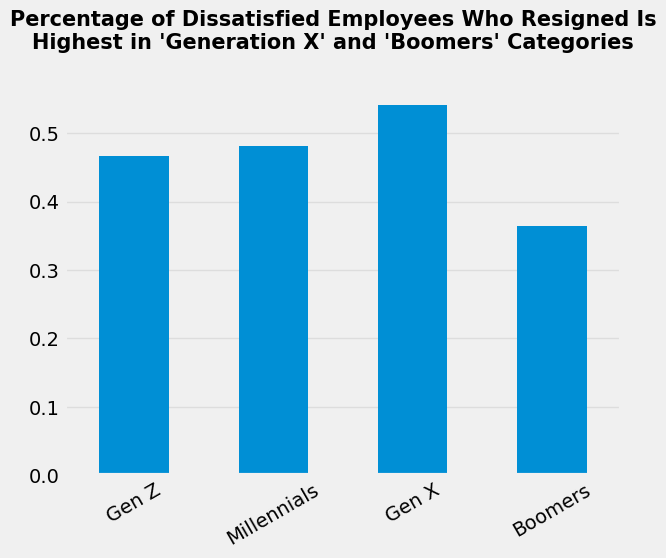

In [91]:
dissat_stat_age=combined_updated.pivot_table(values='dissatisfied',index='age_cat')
plt.figure(figsize=(12, 7))
new_order = ["Gen Z", "Millennials", "Gen X", "Boomers"]
dissat_stat_age=dissat_stat_age.reindex(new_order)
dissat_stat_age.plot(kind='bar',legend=False,rot=30)
plt.suptitle("Percentage of Dissatisfied Employees Who Resigned Is\n\
Highest in 'Generation X' and 'Boomers' Categories", ha="center", weight='bold', size=15, x=0.5, y=1.04)
plt.xlabel('')
plt.grid(axis='x', visible=False)
plt.grid(axis='y', alpha=0.5)
plt.show()

As we can see "Boomers" and "Generation X", people 44 years old and older resign more often due to some kind of dissatisfaction. 

Now let's check if emploees of Tafe or Dete end their employment because of some kind of dissatisfaction.

* #### Comparing the Number of Dissatisfied Employees in Tafe and Dete Institutes <a class="anchor" id="#CTD"></a>

Now let's check in which institutes employees more likely resign due to dissatisfation.
We've added 'imstitute' column after combining our datasets, so it would be easy analyze both institutes separetely.

<Figure size 1200x700 with 0 Axes>

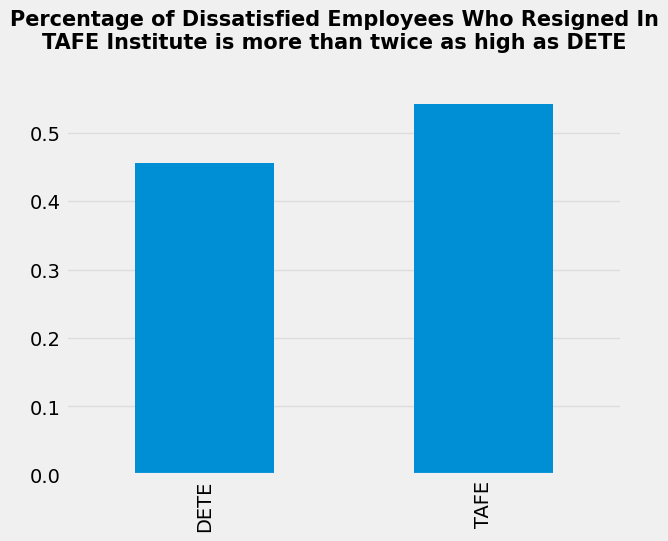

In [100]:
dissat_stat=combined_updated.pivot_table(values='dissatisfied',index='institute')
plt.figure(figsize=(12, 7))
dissat_stat.plot(kind='bar',legend=False)
plt.suptitle("Percentage of Dissatisfied Employees Who Resigned In\n\
TAFE Institute is more than twice as high as DETE", ha="center", weight='bold', size=15, x=0.5, y=1.04)
plt.xlabel('')
plt.grid(axis='x', visible=False)
plt.grid(axis='y', alpha=0.5)
plt.show()

In [98]:
combined_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1524 entries, 0 to 1523
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1524 non-null   float64
 1   separation_type                      651 non-null    object 
 2   cease_date                           1483 non-null   float64
 3   dete_start_date                      749 non-null    float64
 4   role_start_date                      822 non-null    object 
 5   position                             1413 non-null   object 
 6   region                               822 non-null    object 
 7   employment_status                    1413 non-null   object 
 8   career_move_to_public_sector         822 non-null    object 
 9   career_move_to_private_sector        822 non-null    object 
 10  interpersonal_conflicts              822 non-null    object 
 11  job_dissatisfaction           

In [113]:
reason_columns = [
    'career_move_to_public_sector',
    'career_move_to_private_sector',
    'interpersonal_conflicts',
    'job_dissatisfaction',
    'dissatisfaction_with_the_department',
    'physical_work_environment',
    'lack_of_recognition',
    'lack_of_job_security',
    'work_location',
    'employment_conditions',
    'maternity/family',
    'relocation',
    'study/travel',
    'ill_health',
    'traumatic_incident',
   'work_life_balance',
   'workload',
   'none_of_the_above'
]

# Check if exactly one column is True per row
combined_updated['valid_reason_flag'] = (
    combined_updated[reason_columns].sum(axis=1) == 1
)

In [116]:
def get_first_reason(row, reason_columns):
    for col in reason_columns:
        if row[col]:
            return col.replace("career_move_", "").replace("_", " ").title()
    return "Other/Not specified"


combined_updated['career_move_reason'] = combined_updated.apply(
    lambda row: get_first_reason(row, reason_columns),
    axis=1
)

In [117]:
combined_updated['career_move_reason'].value_counts()

career_move_reason
To Public Sector                       724
None Of The Above                      214
Work Life Balance                      104
Ill Health                              82
To Private Sector                       80
Job Dissatisfaction                     71
Maternity/Family                        46
Relocation                              42
Interpersonal Conflicts                 29
Other/Not specified                     27
Dissatisfaction With The Department     26
Study/Travel                            16
Lack Of Job Security                    12
Lack Of Recognition                     12
Physical Work Environment               11
Work Location                           10
Traumatic Incident                       8
Workload                                 7
Employment Conditions                    3
Name: count, dtype: int64

<Figure size 1200x700 with 0 Axes>

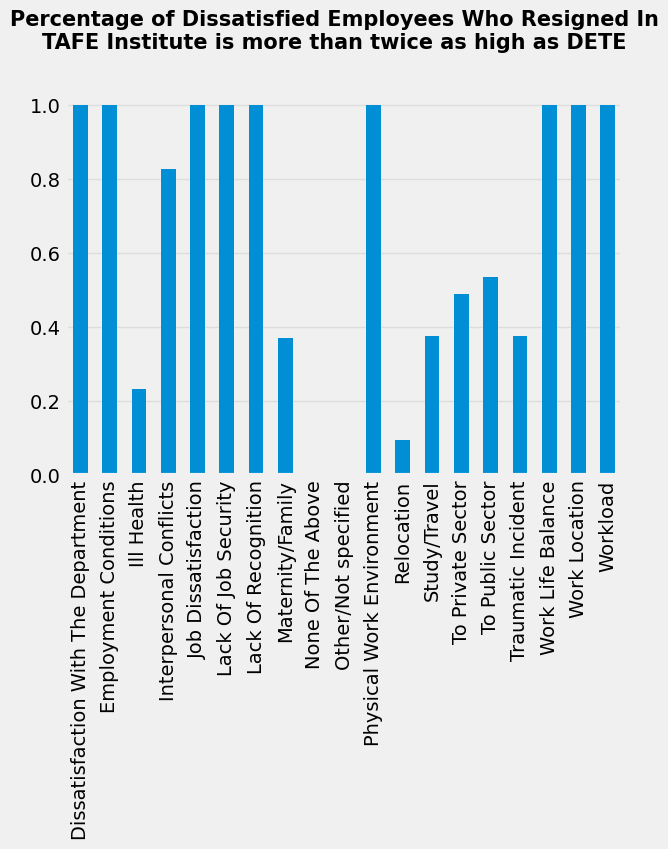

In [118]:
dissat_stat=combined_updated.pivot_table(values='dissatisfied',index='career_move_reason')
plt.figure(figsize=(12, 7))
dissat_stat.plot(kind='bar',legend=False)
plt.suptitle("Percentage of Dissatisfied Employees Who Resigned In\n\
TAFE Institute is more than twice as high as DETE", ha="center", weight='bold', size=15, x=0.5, y=1.04)
plt.xlabel('')
plt.grid(axis='x', visible=False)
plt.grid(axis='y', alpha=0.5)
plt.show()

### Conclusion <a class="anchor" id="Conclusion"></a>

We've analyzed two exit surveys from employees of the Department of Education, Training and Employment (DETE) and the Technical and Further Education (TAFE) institute in Queensland, Australia. 
Answers to the questions we've raised at the beginning of our research are following:

* Are employees who only worked for the institutes for a short period of time resigning due to some kind of dissatisfaction? What about employees who have been there longer? 

- 'Esteblished' and 'Veteran' employees,  with length of service more than 7 years are more likely to resign due to any kind of dissatisfaction.

* Are younger employees resigning due to some kind of dissatisfaction? What about older employees?

- Employees older then 44 years are more likely to resign due to some kind of dissatisfaction than their younger collegues.

* Are employees who work for TAFE or DETE institute more likely to resign due to dissatisfaction?

- The percentage of dissatisfied employees who resign is more than twice as high in DETE institute than in TAFE. 